In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from transformers import CLIPProcessor, CLIPModel
import umap
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd
from PIL import Image
import computing
from data import CIFAKEDataSet
import matplotlib.pyplot as plt
import seaborn as sns

/home/kuniko/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-05-13 08:24:53.701116: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-13 08:24:54.090197: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-13 08:24:54.202350: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDN

In [2]:
root = "../../dataset/CIFAKE/"
save_filepath = f'{root}train.csv'
df_train = pd.read_csv(save_filepath)
save_filepath = f'{root}test.csv'
df_test = pd.read_csv(save_filepath)

In [3]:
id_to_class={0: 'airplane',
             1: 'automobile',
             2: 'bird',
             3: 'cat',
             4: 'deer',
             5: 'dog',
             6: 'frog',
             7: 'horse',
             8: 'ship',
             9: 'truck'}

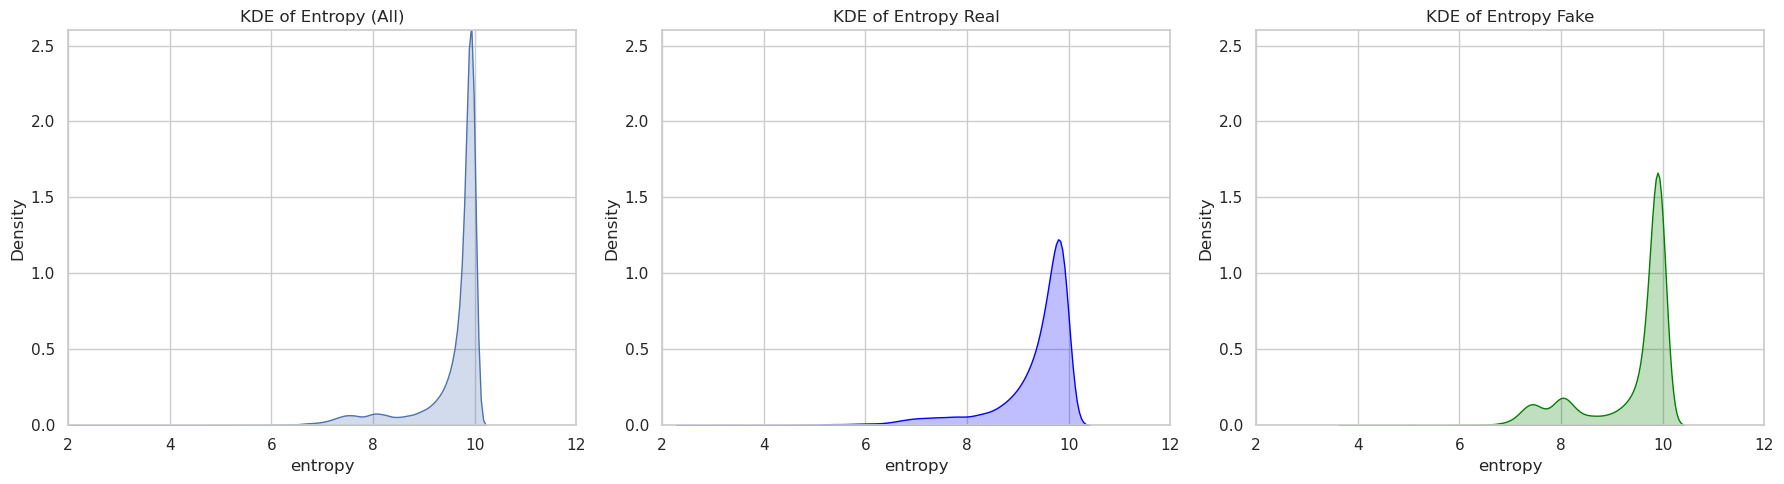

In [4]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1行3列

# KDE 1: 全体
sns.kdeplot(data=df_train, x='entropy', ax=axes[0], fill=True)
axes[0].set_title('KDE of Entropy (All)')
axes[0].set_xlim(2, 12)
axes[0].set_ylim(0, 2.6)

# KDE 2: label == 0
sns.kdeplot(data=df_train[df_train['label'] == 0], x='entropy', ax=axes[1], fill=True, color='blue')
axes[1].set_title('KDE of Entropy Real')
axes[1].set_xlim(2, 12)
axes[1].set_ylim(0, 2.6)

# KDE 3: label == 1
sns.kdeplot(data=df_train[df_train['label'] == 1], x='entropy', ax=axes[2], fill=True, color='green')
axes[2].set_title('KDE of Entropy Fake')
axes[2].set_xlim(2, 12)
axes[2].set_ylim(0, 2.6)

# 余白調整
plt.tight_layout()
plt.show()

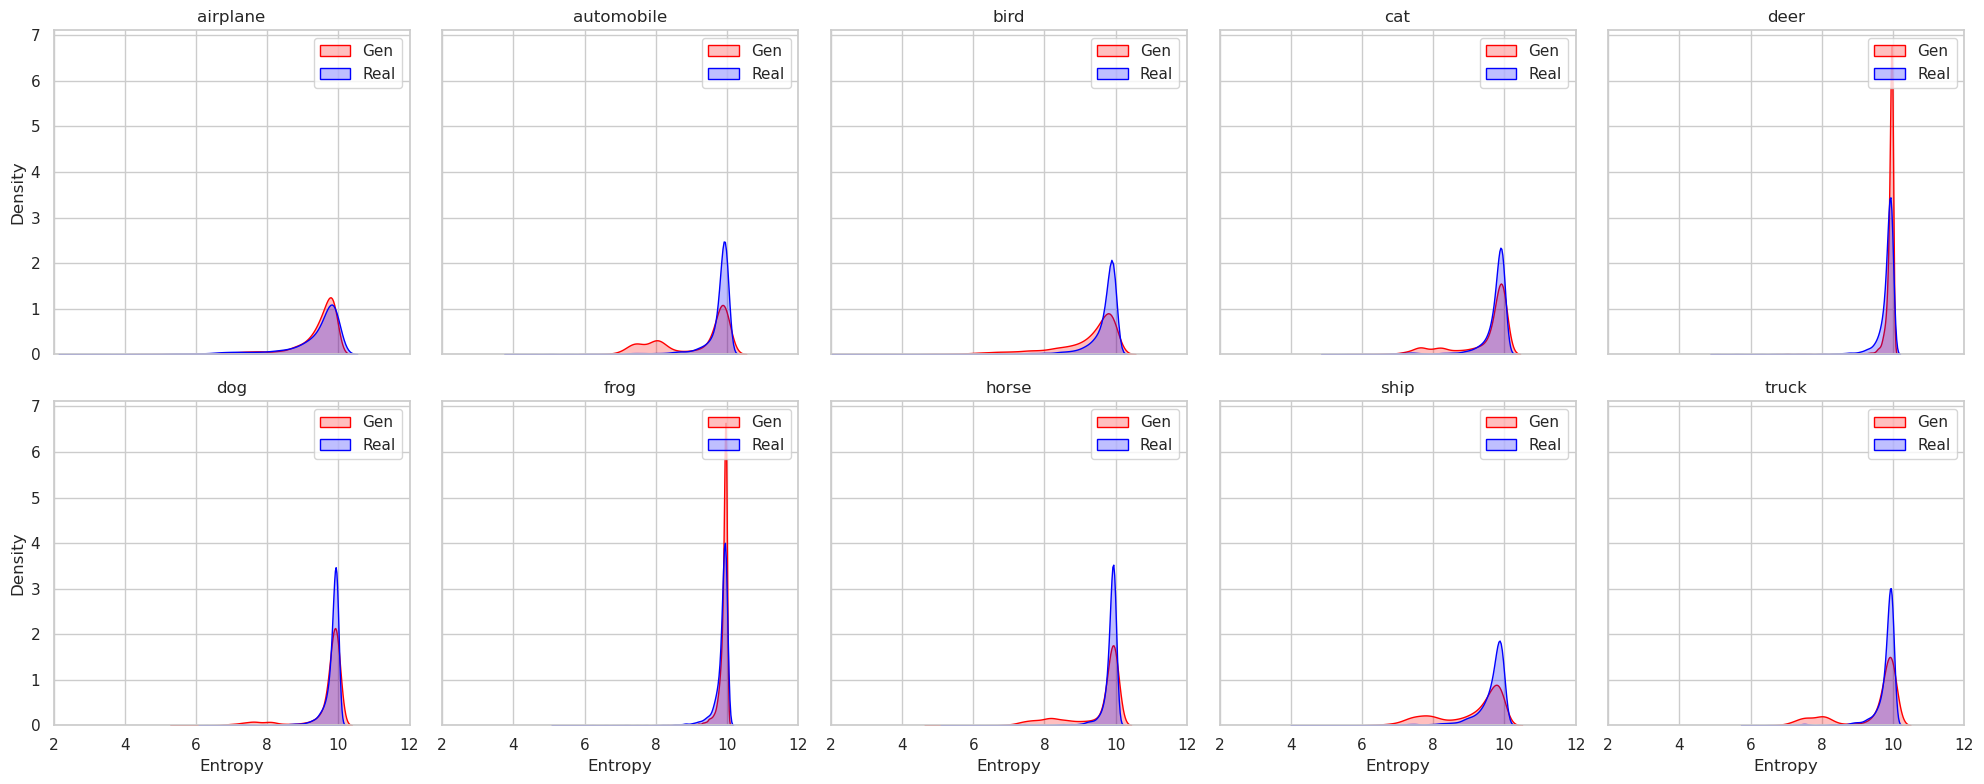

In [9]:
num_classes = len(id_to_class)
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()  # 1次元配列に変換して扱いやすくする

for class_id in range(num_classes):
    df_class = df_train[df_train['label'] == class_id]
    
    ax = axes[class_id]
    sns.kdeplot(data=df_class[df_class['real'] == 0], x='entropy', ax=ax, fill=True, color='red', label='Gen')
    sns.kdeplot(data=df_class[df_class['real'] == 1], x='entropy', ax=ax, fill=True, color='blue', label='Real')

    ax.set_title(f'{id_to_class[class_id]}')
    ax.set_xlim(2, 12)
    ax.set_xlabel('Entropy')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
save_filepath = f'{root}figures/rgb_entropy.png'
plt.savefig(save_filepath)
plt.show()

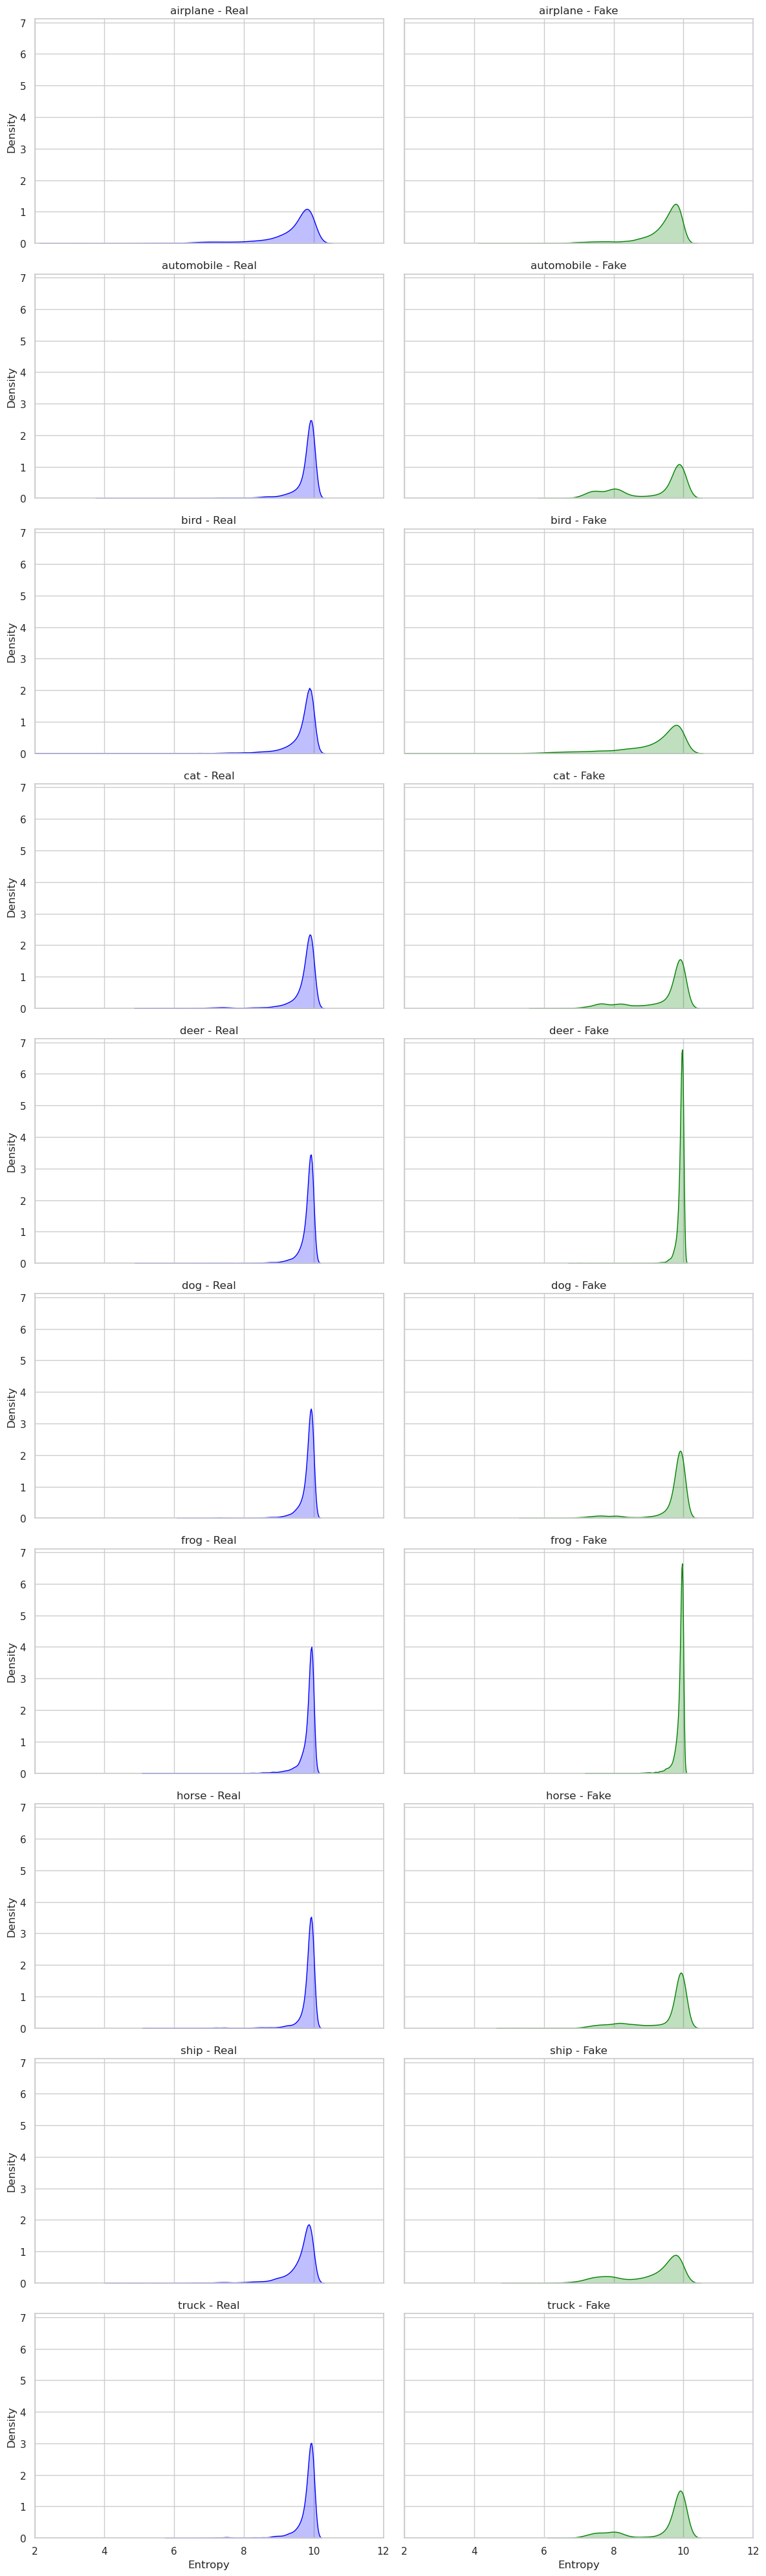

In [5]:
num_classes = len(id_to_class)
fig, axes = plt.subplots(num_classes, 2, figsize=(12, 4 * num_classes), sharex=True, sharey=True)

for class_id in range(num_classes):
    df_class = df_train[df_train['class_id'] == class_id]

    # Real
    sns.kdeplot(data=df_class[df_class['label'] == 0], x='entropy', ax=axes[class_id, 0], fill=True, color='blue')
    axes[class_id, 0].set_title(f'{id_to_class[class_id]} - Real')
    axes[class_id, 0].set_xlim(2, 12)

    # Fake
    sns.kdeplot(data=df_class[df_class['label'] == 1], x='entropy', ax=axes[class_id, 1], fill=True, color='green')
    axes[class_id, 1].set_title(f'{id_to_class[class_id]} - Fake')
    axes[class_id, 1].set_xlim(2, 12)

# 軸ラベルや余白調整
for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel('Entropy')
        ax.set_ylabel('Density')

plt.tight_layout()
plt.show()


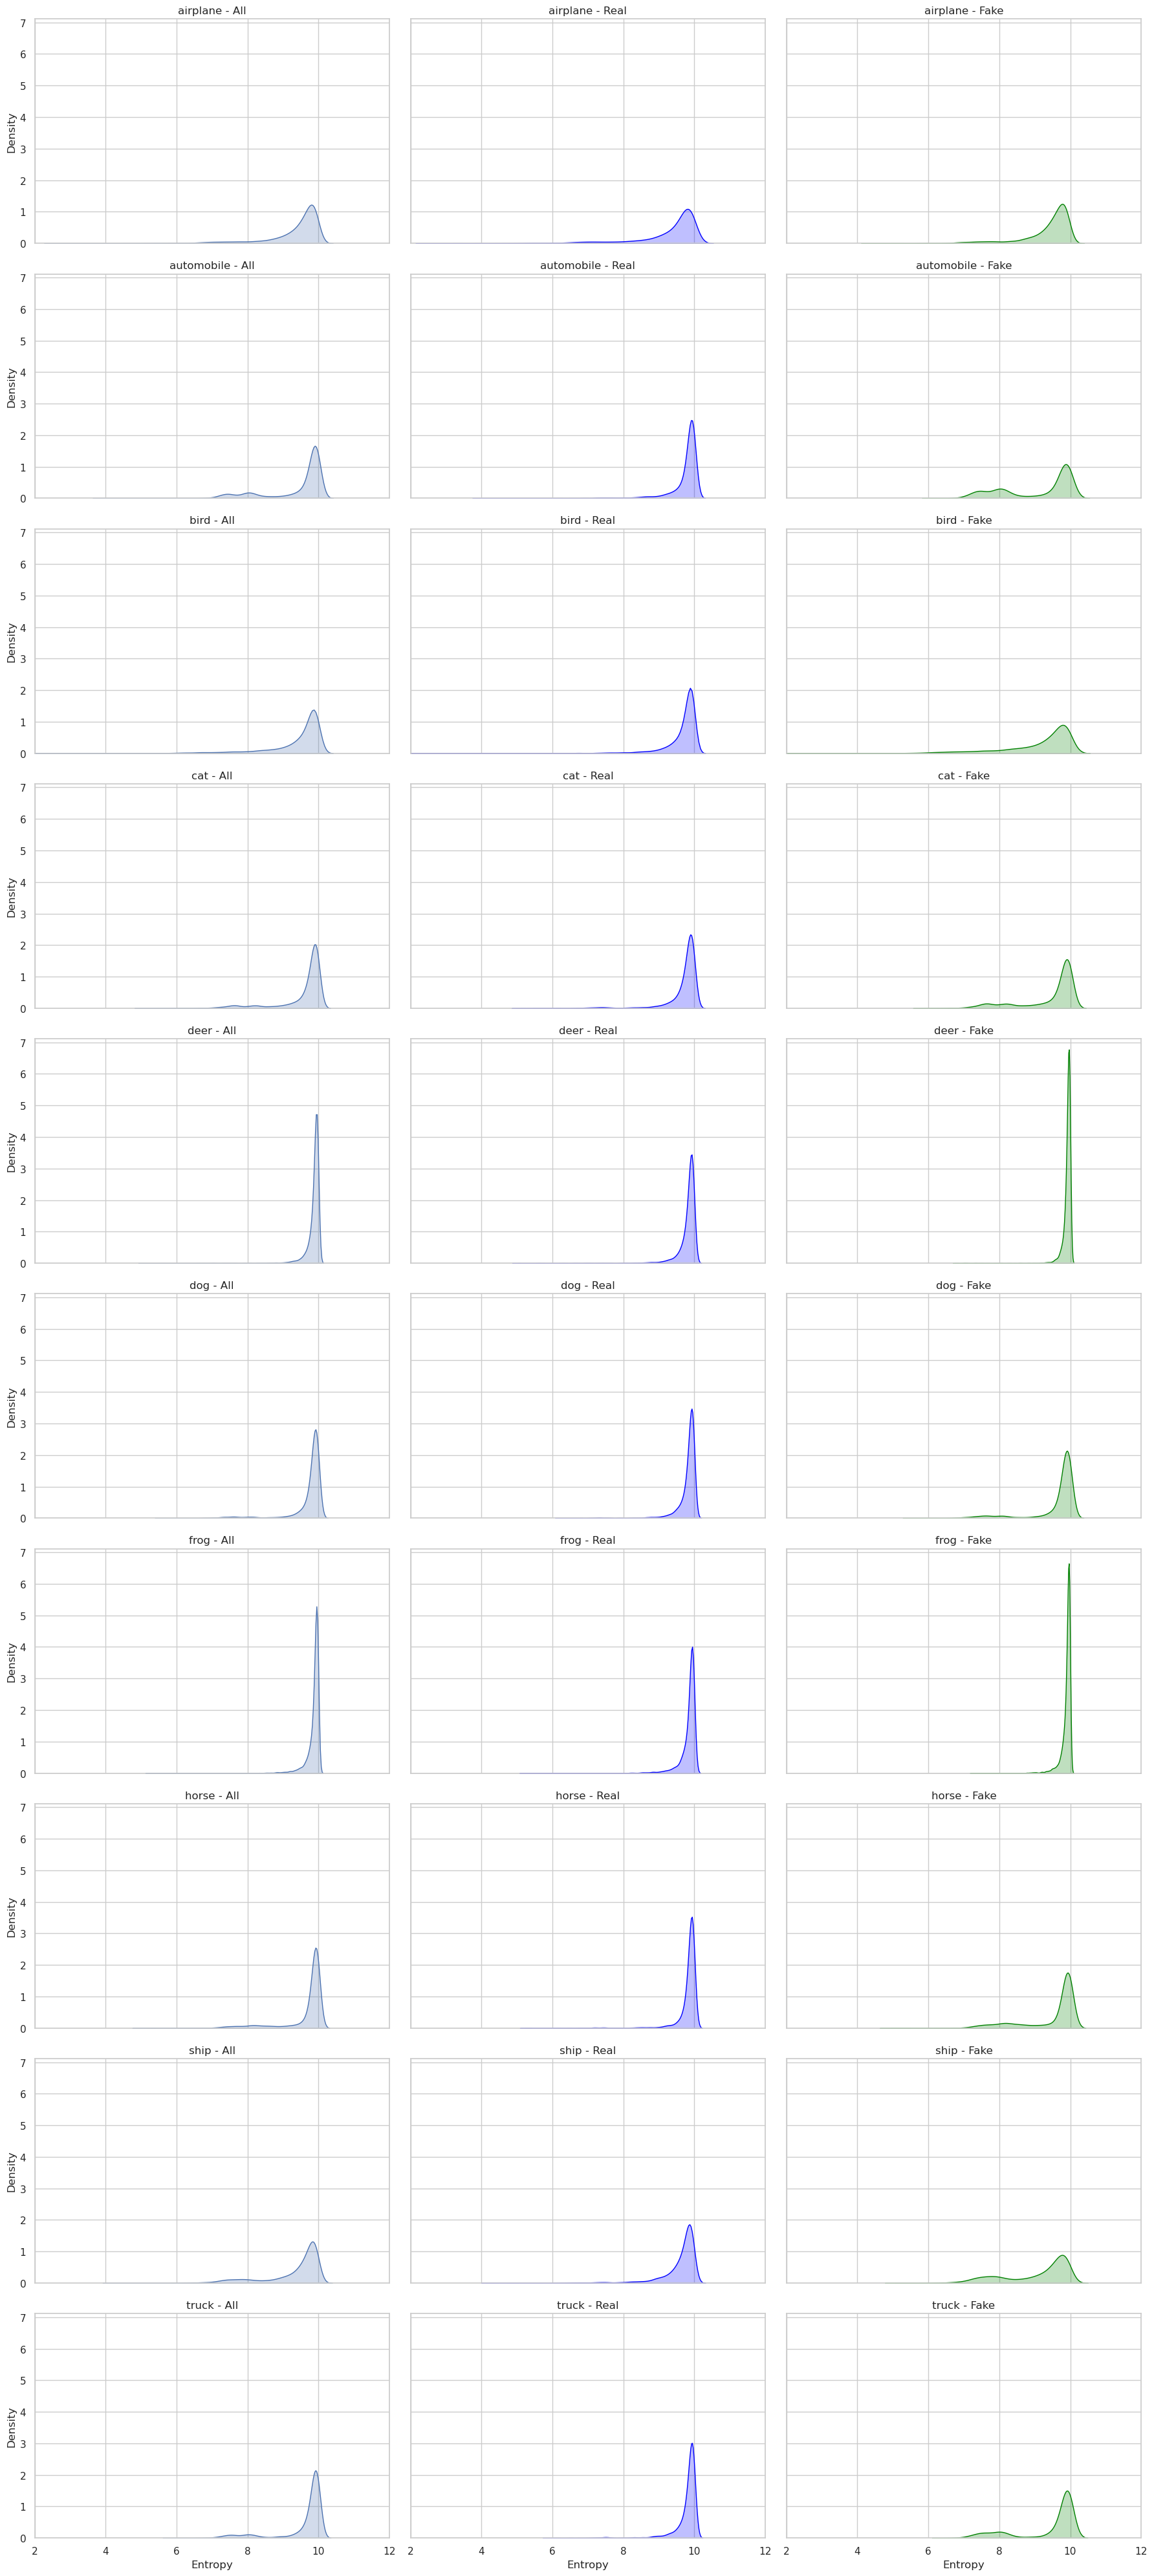

In [8]:
num_classes = len(id_to_class)
fig, axes = plt.subplots(num_classes, 3, figsize=(18, 4 * num_classes), sharex=True, sharey=True)

for class_id in range(num_classes):
    df_class = df_train[df_train['class_id'] == class_id]

    # 全体
    sns.kdeplot(data=df_class, x='entropy', ax=axes[class_id, 0], fill=True)
    axes[class_id, 0].set_title(f'{id_to_class[class_id]} - All')
    axes[class_id, 0].set_xlim(2, 12)

    # Real
    sns.kdeplot(data=df_class[df_class['label'] == 0], x='entropy', ax=axes[class_id, 1], fill=True, color='blue')
    axes[class_id, 1].set_title(f'{id_to_class[class_id]} - Real')
    axes[class_id, 1].set_xlim(2, 12)

    # Fake
    sns.kdeplot(data=df_class[df_class['label'] == 1], x='entropy', ax=axes[class_id, 2], fill=True, color='green')
    axes[class_id, 2].set_title(f'{id_to_class[class_id]} - Fake')
    axes[class_id, 2].set_xlim(2, 12)

# 軸ラベルや余白調整
for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel('Entropy')
        ax.set_ylabel('Density')

plt.tight_layout()
plt.show()